In [1]:
# =============================================================================
# 0. Imports et rechargement des données
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import seaborn as sns
from pathlib import Path
from collections import Counter
import re
import string
import os
import json
import urllib.request

# Recharger les données
df = pd.read_pickle("../data/df_complet.pkl")
print(f"DataFrame chargé : {len(df)} lignes, {len(df.columns)} colonnes")

DataFrame chargé : 12746 lignes, 47 colonnes


In [2]:
# =============================================================================
# 1. Statistiques descriptives du corpus
# =============================================================================
print("\n=== Répartition par année ===")
print(df['year'].value_counts().sort_index())

print("\n=== Répartition par type d'élection ===")
print(df['election_type'].value_counts())

print("\n=== Top 15 des partis (titulaire-soutien) ===")
print(df['titulaire-soutien'].value_counts().head(15))

print("\n=== Répartition par sexe ===")
print(df['titulaire-sexe'].value_counts())

print("\n=== Répartition par tranche d'âge ===")
print(df['titulaire-age-tranche'].value_counts())


=== Répartition par année ===
year
1981    3182
1988    3628
1993    5936
Name: count, dtype: int64

=== Répartition par type d'élection ===
election_type
legislatives    12746
Name: count, dtype: int64

=== Top 15 des partis (titulaire-soutien) ===
titulaire-soutien
non mentionné                                                          3035
Parti communiste français                                              1532
Front national                                                         1233
Parti socialiste                                                        989
Rassemblement pour la République;Union pour la démocratie française     759
Union pour la démocratie française;Rassemblement pour la République     454
Lutte ouvrière                                                          393
Nouveaux écologistes du rassemblement nature et animaux                 387
Verts;Génération écologie                                               293
Rassemblement pour la République               

In [3]:
# =============================================================================
# Nettoyage du texte
# =============================================================================
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = text.replace('\n', ' ').replace('\r', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_text)

print("=== Exemple de texte original ===")
print(df['text'].iloc[0][:300])
print("\n=== Exemple de texte nettoyé ===")
print(df['text_clean'].iloc[0][:300])

=== Exemple de texte original ===
Sciences Po / fonds CEVIPOF
RÉPUBLIQUE FRANÇAISE - DÉPARTEMENT DES ALPES-MARITIMES ÉLECTIONS LÉGISLATIVES - 21 ET 28 MARS 1993 8e CIRCONSCRIPTION de CANNES-MANDELIEU-THÉOULE
MICHEL MOUILLOT
POUR L'AVENIR
Madame, Mademoiselle, Monsieur,
Le 21 mars, vous allez voter pour choisir le député qui vous rep

=== Exemple de texte nettoyé ===
sciences po fonds cevipof république française département des alpesmaritimes élections législatives et mars e circonscription de cannesmandelieuthéoule michel mouillot pour lavenir madame mademoiselle monsieur le mars vous allez voter pour choisir le député qui vous représentera à lassemblée nation


In [4]:
# =============================================================================
# Stopwords et tokenisation
# =============================================================================
STOPWORDS_FR = {
    'le', 'la', 'les', 'de', 'des', 'du', 'un', 'une', 'et', 'en', 'à',
    'au', 'aux', 'ce', 'ces', 'que', 'qui', 'dans', 'pour', 'par', 'sur',
    'avec', 'son', 'ses', 'sa', 'se', 'ne', 'pas', 'nous', 'vous', 'ils',
    'est', 'sont', 'ont', 'été', 'être', 'avoir', 'fait', 'faire', 'plus',
    'tout', 'tous', 'toute', 'toutes', 'mais', 'ou', 'où', 'si', 'leur',
    'leurs', 'elle', 'elles', 'il', 'je', 'me', 'mon', 'ma', 'mes',
    'notre', 'nos', 'votre', 'vos', 'même', 'aussi', 'bien', 'peut',
    'cette', 'cet', 'dont', 'comme', 'sans', 'entre', 'très', 'après',
    'avant', 'autres', 'autre', 'encore', 'quand', 'car', 'donc',
    'sera', 'été', 'non', 'oui', 'puis', 'ici', 'là',
    'ya', 'ça', 'cela', 'ceci', 'on', 'ny', 'na', 'ni',
    'circonscription', 'candidat', 'candidate', 'élections', 'législatives',
    'république', 'française', 'france', 'département', 'juin', 'mars',
    'tour', 'scrutin', 'vote', 'voter', 'électeurs', 'électeur'
}

def tokenize(text):
    tokens = text.split()
    return [t for t in tokens if t not in STOPWORDS_FR and len(t) > 2]

df['tokens'] = df['text_clean'].apply(tokenize)
df['n_tokens'] = df['tokens'].apply(len)

print(f"\nNombre moyen de tokens par document : {df['n_tokens'].mean():.0f}")
print(f"Exemple de tokens : {df['tokens'].iloc[0][:20]}")

def get_top_words(df_subset, n=20):
    all_tokens = [token for tokens in df_subset['tokens'] for token in tokens]
    return Counter(all_tokens).most_common(n)

print("\n=== Top 20 mots globaux ===")
for word, count in get_top_words(df):
    print(f"  {word}: {count}")


Nombre moyen de tokens par document : 320
Exemple de tokens : ['sciences', 'fonds', 'cevipof', 'alpesmaritimes', 'cannesmandelieuthéoule', 'michel', 'mouillot', 'lavenir', 'madame', 'mademoiselle', 'monsieur', 'allez', 'choisir', 'député', 'représentera', 'lassemblée', 'nationale', 'cest', 'lui', 'demain']

=== Top 20 mots globaux ===
  fonds: 27377
  cest: 25273
  politique: 23325
  cevipof: 22670
  sciences: 18717
  ans: 17657
  français: 17498
  gauche: 16231
  majorité: 14803
  droite: 14710
  parti: 14004
  faut: 13744
  nationale: 13700
  contre: 13466
  pays: 13262
  vie: 12133
  député: 12072
  candidats: 11731
  votez: 11144
  suppléant: 11033


In [5]:
# =============================================================================
# Regroupement des partis politiques
# =============================================================================
def classify_party(soutien):
    if not isinstance(soutien, str):
        return 'Autre'
    soutien = soutien.lower()
    if any(x in soutien for x in ['communiste', 'pcf']):
        return 'PCF'
    if any(x in soutien for x in ['socialiste', 'ps ', 'parti socialiste']):
        return 'PS'
    if any(x in soutien for x in ['rassemblement pour la république', 'rpr', 'gaulliste']):
        return 'RPR'
    if any(x in soutien for x in ['union pour la démocratie française', 'udf']):
        return 'UDF'
    if any(x in soutien for x in ['front national', 'fn']):
        return 'FN'
    if any(x in soutien for x in ['écologi', 'vert']):
        return 'Ecologistes'
    if any(x in soutien for x in ['radical']):
        return 'Radicaux'
    if 'non mentionné' in soutien:
        return 'Non mentionné'
    return 'Autre'

df['parti_famille'] = df['titulaire-soutien'].apply(classify_party)

print("\n=== Répartition par famille politique ===")
print(df['parti_famille'].value_counts())


=== Répartition par famille politique ===
parti_famille
Non mentionné    3035
Autre            1949
RPR              1803
PCF              1765
PS               1482
FN               1241
Ecologistes      1202
UDF               254
Radicaux           15
Name: count, dtype: int64


In [6]:
# =============================================================================
# Classification des professions — BERT zero-shot AVEC CACHE
# =============================================================================
import os
import json

CACHE_PATH = "../data/profession_pcs_mapping.json"

PCS_CATEGORIES = [
    "Agriculteur, exploitant agricole",
    "Artisan, commerçant, chef d'entreprise",
    "Profession médicale ou paramédicale",
    "Profession juridique",
    "Enseignant, chercheur, universitaire",
    "Cadre supérieur, ingénieur",
    "Cadre moyen, technicien",
    "Employé, fonctionnaire",
    "Ouvrier",
    "Journaliste, artiste, communication",
    "Militaire, policier, sécurité",
    "Profession commerciale, vente",
    "Étudiant, retraité, sans emploi",
    "Permanent politique ou syndical",
    "Profession religieuse",
]

if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, 'r', encoding='utf-8') as f:
        results = json.load(f)
    print(f"Cache chargé : {len(results)} professions mappées depuis {CACHE_PATH}")

else:
    print("Pas de cache trouvé → lancement de la classification BERT...")
    print("(Ce calcul ne sera fait qu'une seule fois, les résultats seront sauvegardés)\n")

    # Installer sentencepiece si absent (nécessaire pour XLM-RoBERTa)
    try:
        import sentencepiece
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install",
                               "sentencepiece", "protobuf", "--quiet"])
        print("sentencepiece installé — REDÉMARRE LE KERNEL puis relance cette cellule.")
        raise SystemExit("Redémarrage du kernel nécessaire après installation de sentencepiece.")

    import torch
    from transformers import XLMRobertaTokenizer, AutoModelForSequenceClassification, pipeline
    from tqdm import tqdm

    # Charger le tokenizer "slow" (basé sur sentencepiece, pas tiktoken)
    tokenizer = XLMRobertaTokenizer.from_pretrained("joeddav/xlm-roberta-large-xnli")
    model = AutoModelForSequenceClassification.from_pretrained("joeddav/xlm-roberta-large-xnli")

    classifier = pipeline(
        "zero-shot-classification",
        model=model,
        tokenizer=tokenizer,
        device=-1
    )

    unique_professions = df['titulaire-profession'].dropna().unique()
    to_classify = [p for p in unique_professions
                   if isinstance(p, str) and p.lower().strip() not in ['non mentionné', '']]
    print(f"Professions uniques à classifier : {len(unique_professions)}")
    print(f"Professions à envoyer au modèle : {len(to_classify)}")

    results = {}
    batch_size = 16

    for i in tqdm(range(0, len(to_classify), batch_size), desc="Classification"):
        batch = to_classify[i:i+batch_size]
        for profession in batch:
            try:
                result = classifier(
                    profession,
                    candidate_labels=PCS_CATEGORIES,
                    hypothesis_template="Cette personne travaille comme {}."
                )
                results[profession] = result['labels'][0]
            except Exception as e:
                results[profession] = 'Autre'

    for p in unique_professions:
        if p not in results:
            results[p] = 'Non renseigné'

    with open(CACHE_PATH, 'w', encoding='utf-8') as f:
        json.dump(results, f, ensure_ascii=False, indent=2)
    print(f"\nCache sauvegardé dans {CACHE_PATH}")

# Appliquer le mapping au DataFrame
df['profession_pcs'] = df['titulaire-profession'].map(results)
df['profession_pcs'] = df['profession_pcs'].fillna('Non renseigné')

print("\n=== Répartition par catégorie PCS ===\n")
pcs_counts = df['profession_pcs'].value_counts()
for cat, count in pcs_counts.items():
    pct = count / len(df) * 100
    print(f"  {cat:50s} {count:5d}  ({pct:5.1f}%)")
print(f"\nTotal : {len(df)}")

Pas de cache trouvé → lancement de la classification BERT...
(Ce calcul ne sera fait qu'une seule fois, les résultats seront sauvegardés)



/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 393/393 [00:00<00:00, 6868.34it/s]
XLMRobertaForSequenceClassification LOAD REPORT from: joeddav/xlm-roberta-large-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Professions uniques à classifier : 2032
Professions à envoyer au modèle : 2031


Classification: 100%|██████████| 127/127 [1:52:55<00:00, 53.35s/it]


Cache sauvegardé dans ../data/profession_pcs_mapping.json

=== Répartition par catégorie PCS ===

  Non renseigné                                       6596  ( 51.7%)
  Enseignant, chercheur, universitaire                1456  ( 11.4%)
  Profession juridique                                1157  (  9.1%)
  Employé, fonctionnaire                              1030  (  8.1%)
  Ouvrier                                              628  (  4.9%)
  Cadre supérieur, ingénieur                           557  (  4.4%)
  Profession commerciale, vente                        396  (  3.1%)
  Cadre moyen, technicien                              357  (  2.8%)
  Agriculteur, exploitant agricole                     249  (  2.0%)
  Journaliste, artiste, communication                   95  (  0.7%)
  Profession religieuse                                 73  (  0.6%)
  Artisan, commerçant, chef d'entreprise                51  (  0.4%)
  Profession médicale ou paramédicale                   43  (  0.3%)
  Mi

In [7]:
# =============================================================================
# 2. Configuration esthétique
# =============================================================================
FONT_DIR = os.path.expanduser("~/.fonts")
os.makedirs(FONT_DIR, exist_ok=True)

fonts_to_download = {
    "Playfair Display": "https://github.com/google/fonts/raw/main/ofl/playfairdisplay/PlayfairDisplay%5Bwght%5D.ttf",
    "Source Sans 3": "https://github.com/google/fonts/raw/main/ofl/sourcesans3/SourceSans3%5Bwght%5D.ttf",
}

for name, url in fonts_to_download.items():
    path = os.path.join(FONT_DIR, f"{name}.ttf")
    if not os.path.exists(path):
        urllib.request.urlretrieve(url, path)
        print(f"Téléchargé : {name}")

font_manager.fontManager.addfont(os.path.join(FONT_DIR, "Playfair Display.ttf"))
font_manager.fontManager.addfont(os.path.join(FONT_DIR, "Source Sans 3.ttf"))

FONT_TITLE = 'Playfair Display'
FONT_BODY = 'Source Sans 3'

PARTY_COLORS = {
    'PCF':            '#D4626E',
    'PS':             '#E8919A',
    'Radicaux':       '#F0B87E',
    'Ecologistes':    '#8CBF8C',
    'UDF':            '#7EADD4',
    'RPR':            '#5B8DB8',
    'FN':             '#2E4A62',
    'Non mentionné':  '#C4BFB6',
    'Autre':          '#A89F96',
}

YEAR_COLORS = {
    '1981': '#D4626E',
    '1988': '#7EADD4',
    '1993': '#5B8DB8',
}

BG_COLOR = '#FAF7F2'
TEXT_COLOR = '#2C2824'
GRID_COLOR = '#E8E4DD'
ACCENT_COLOR = '#D4626E'

plt.rcParams.update({
    'figure.facecolor': BG_COLOR,
    'axes.facecolor': BG_COLOR,
    'axes.edgecolor': GRID_COLOR,
    'axes.labelcolor': TEXT_COLOR,
    'text.color': TEXT_COLOR,
    'xtick.color': TEXT_COLOR,
    'ytick.color': TEXT_COLOR,
    'grid.color': GRID_COLOR,
    'grid.alpha': 0.5,
    'font.family': FONT_BODY,
    'font.size': 11,
    'axes.titlesize': 16,
    'axes.labelsize': 12,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print("Style configuré ✓")

Style configuré ✓


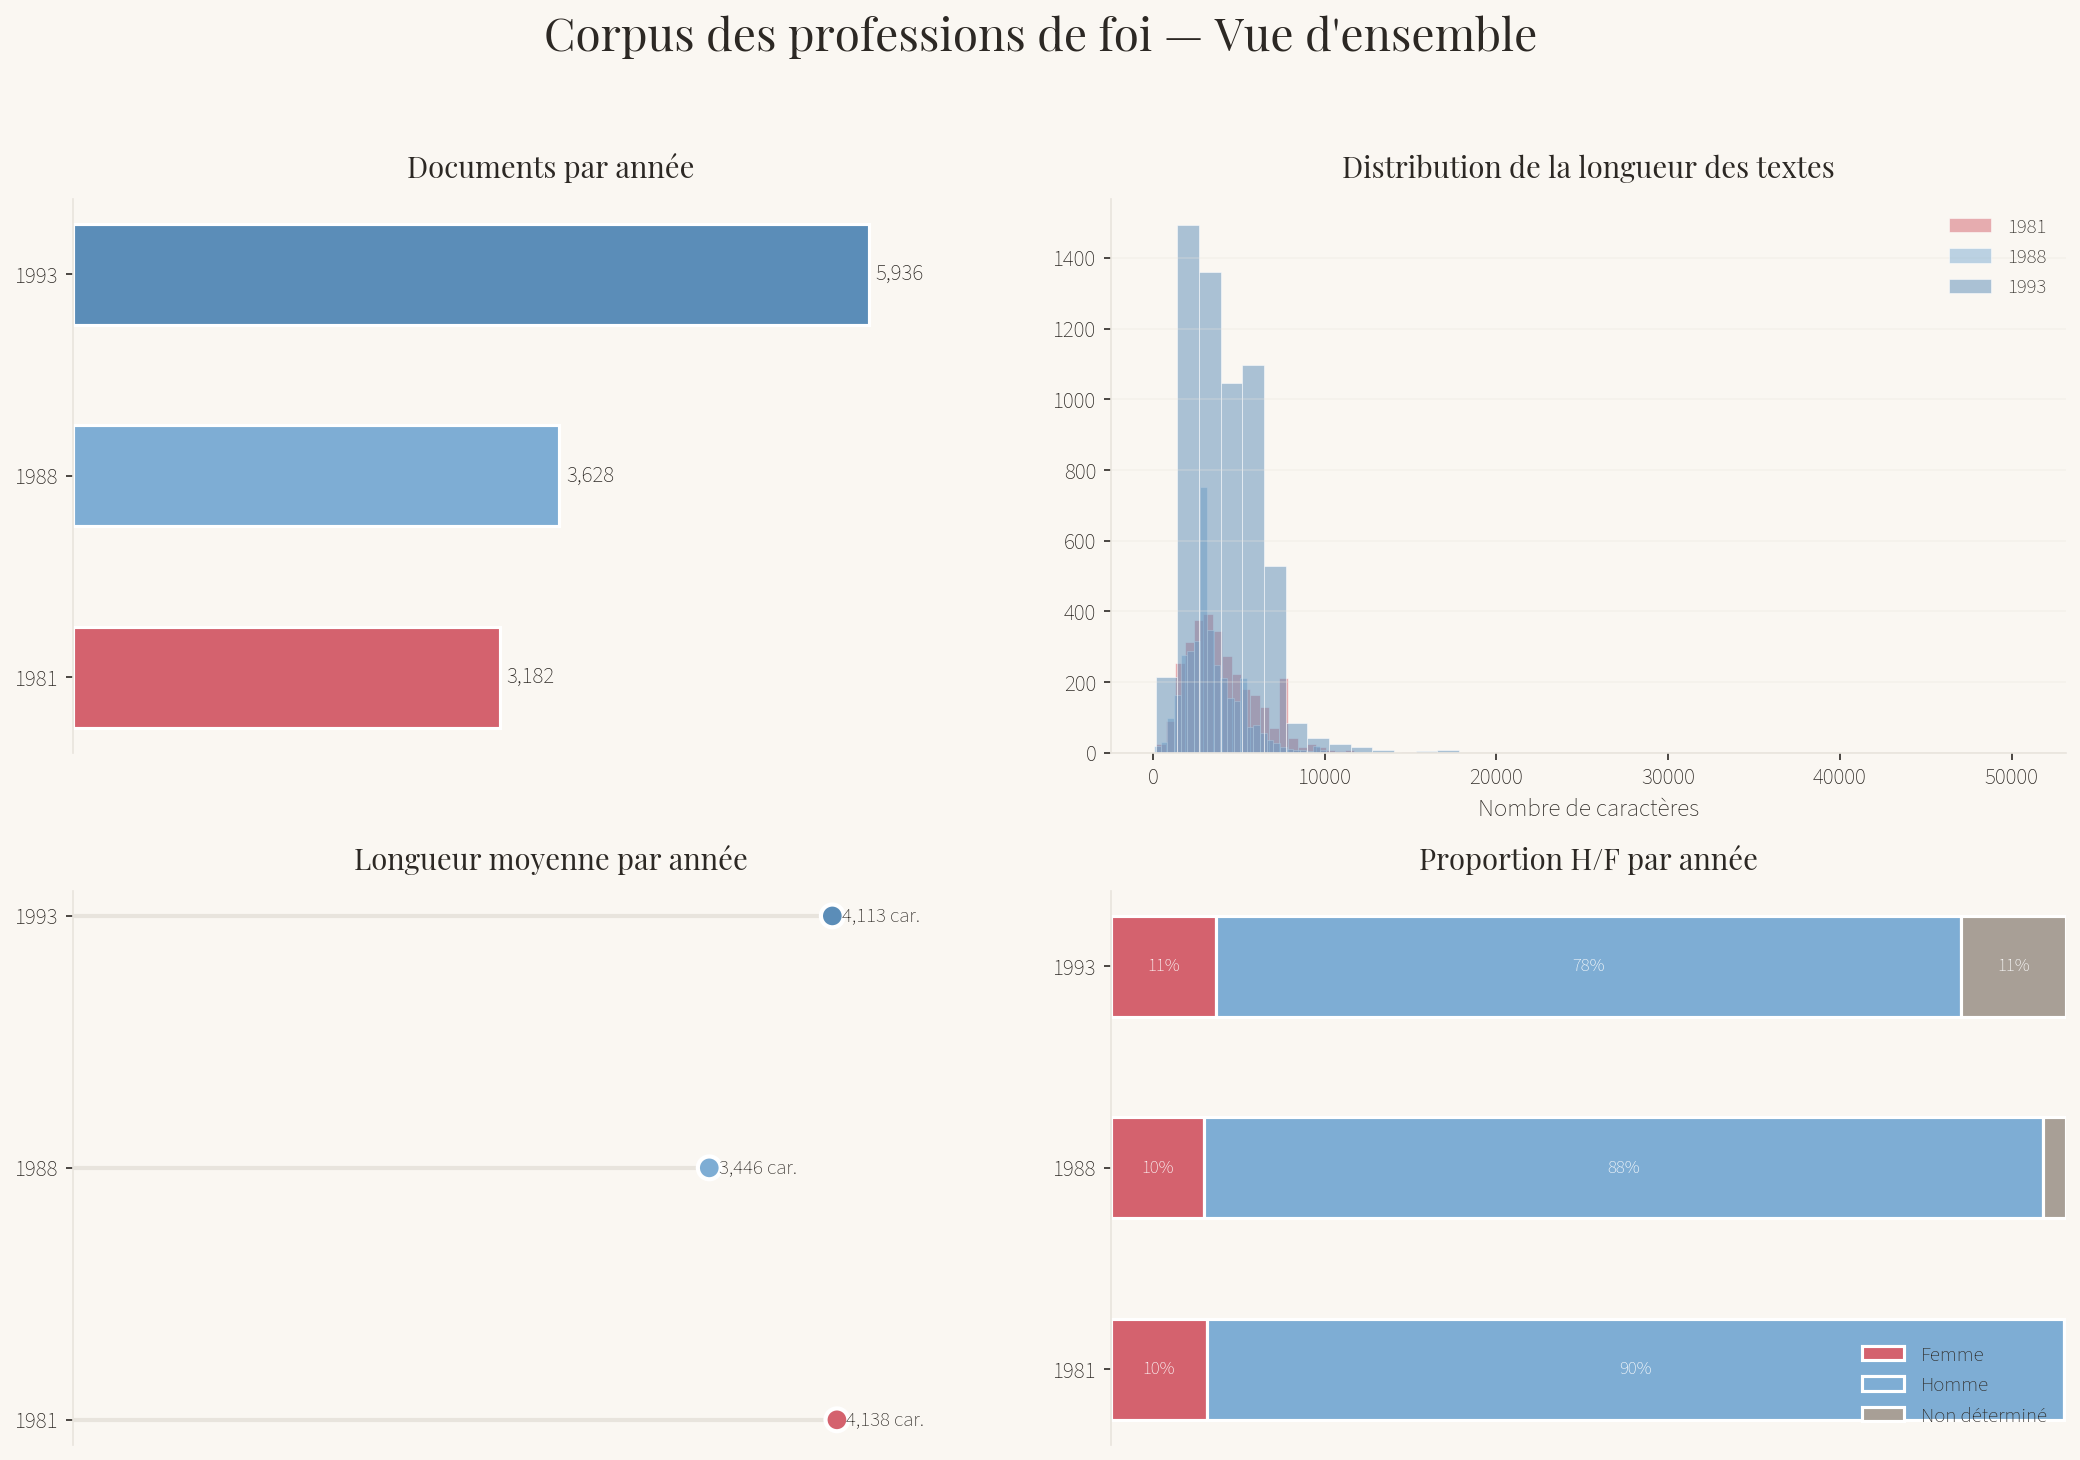

In [8]:
# =============================================================================
# 3. Figure 1 — Vue d'ensemble du corpus (2×2)
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Corpus des professions de foi — Vue d'ensemble",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.97, color=TEXT_COLOR)

# 3a. Documents par année
ax = axes[0, 0]
year_counts = df['year'].value_counts().sort_index()
bars = ax.barh(year_counts.index, year_counts.values, height=0.5,
               color=[YEAR_COLORS.get(y, '#A89F96') for y in year_counts.index],
               edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, year_counts.values):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=11, fontweight='bold', color=TEXT_COLOR)
ax.set_title("Documents par année", fontfamily=FONT_TITLE, fontsize=14, pad=10)
ax.set_xlim(0, year_counts.max() * 1.2)
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)

# 3b. Distribution longueur
ax = axes[0, 1]
for year in sorted(df['year'].unique()):
    subset = df[df['year'] == year]['text_length']
    ax.hist(subset, bins=40, alpha=0.5, label=year,
            color=YEAR_COLORS.get(year, '#A89F96'), edgecolor='white', linewidth=0.5)
ax.set_title("Distribution de la longueur des textes", fontfamily=FONT_TITLE, fontsize=14, pad=10)
ax.set_xlabel("Nombre de caractères")
ax.legend(frameon=False, fontsize=10)
ax.grid(axis='y', alpha=0.3)

# 3c. Longueur moyenne par année
ax = axes[1, 0]
mean_lengths = df.groupby('year')['text_length'].mean().sort_index()
ax.hlines(mean_lengths.index, 0, mean_lengths.values, color=GRID_COLOR, linewidth=2)
ax.scatter(mean_lengths.values, mean_lengths.index, s=120, zorder=3,
           color=[YEAR_COLORS.get(y, '#A89F96') for y in mean_lengths.index],
           edgecolors='white', linewidth=2)
for y, val in zip(mean_lengths.index, mean_lengths.values):
    ax.text(val + 50, y, f'{val:,.0f} car.', va='center', fontsize=10, color=TEXT_COLOR)
ax.set_title("Longueur moyenne par année", fontfamily=FONT_TITLE, fontsize=14, pad=10)
ax.set_xlim(0, mean_lengths.max() * 1.25)
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)

# 3d. Répartition H/F par année
ax = axes[1, 1]
ct = pd.crosstab(df['year'], df['titulaire-sexe'], normalize='index') * 100
ct_sorted = ct.sort_index()
colors_sexe = {'homme': '#7EADD4', 'femme': ACCENT_COLOR}
col_names = ct_sorted.columns.tolist()
bottom = np.zeros(len(ct_sorted))
for col in col_names:
    color = colors_sexe.get(col, '#A89F96')
    ax.barh(ct_sorted.index, ct_sorted[col], left=bottom, height=0.5,
            label=col.capitalize(), color=color, edgecolor='white', linewidth=1.5)
    for i, (val, b) in enumerate(zip(ct_sorted[col], bottom)):
        if val > 5:
            ax.text(b + val/2, ct_sorted.index[i], f'{val:.0f}%',
                    ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    bottom += ct_sorted[col].values
ax.set_title("Proportion H/F par année", fontfamily=FONT_TITLE, fontsize=14, pad=10)
ax.set_xlim(0, 100)
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.legend(frameon=False, loc='lower right', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("../data/exploration_base.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

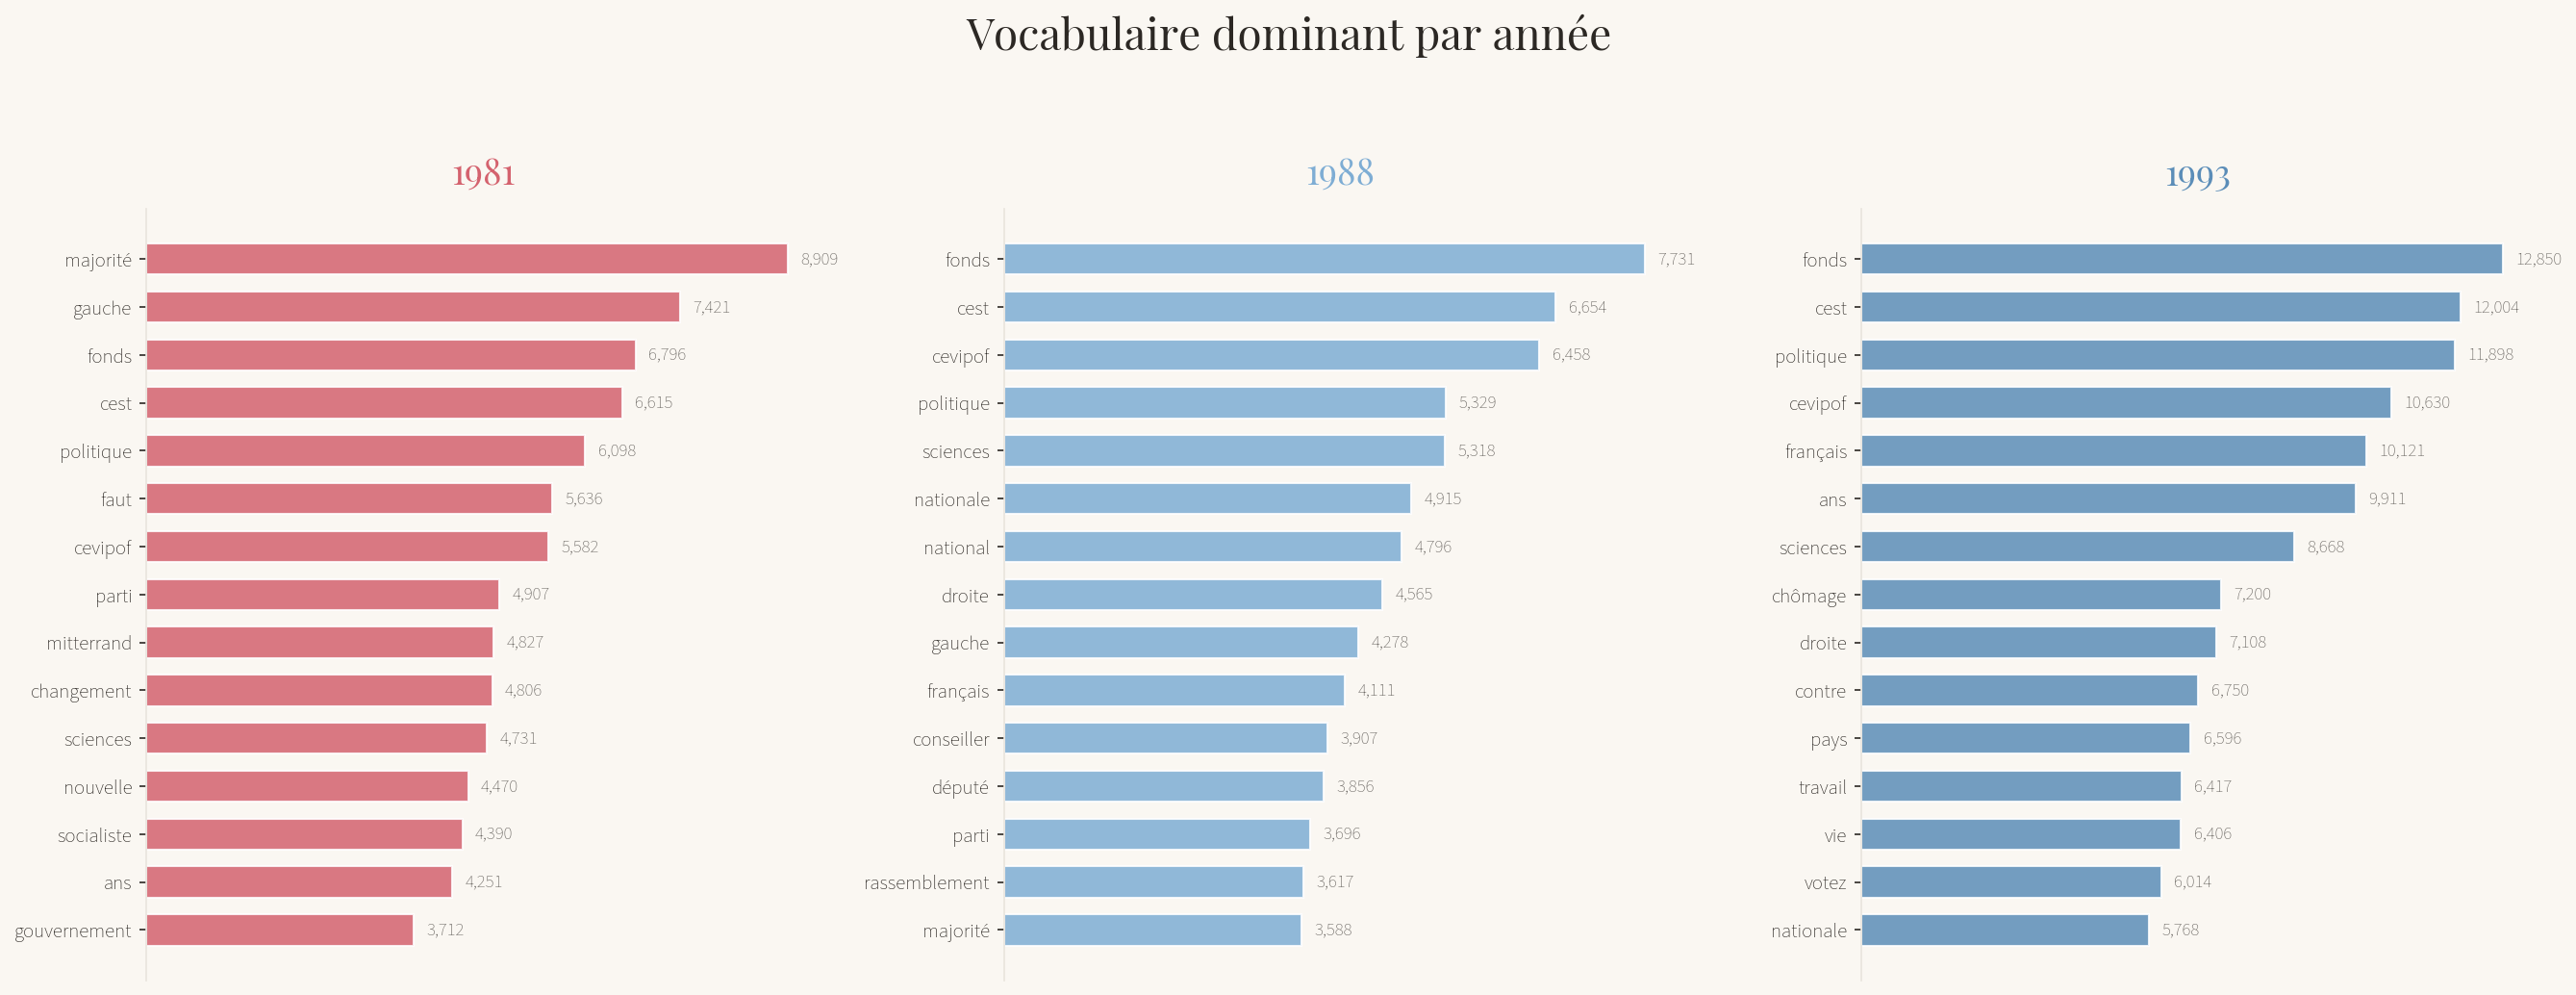

In [9]:
# =============================================================================
# 4. Figure 2 — Top mots par année
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Vocabulaire dominant par année",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.98, color=TEXT_COLOR)

for i, year in enumerate(sorted(df['year'].unique())):
    ax = axes[i]
    top = get_top_words(df[df['year'] == year], 15)
    words, counts = zip(*top)
    max_count = max(counts)

    color = YEAR_COLORS.get(year, '#A89F96')
    bars = ax.barh(range(len(words)), counts, height=0.65,
                   color=color, alpha=0.85, edgecolor='white', linewidth=1)

    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=10, fontfamily=FONT_BODY)
    ax.invert_yaxis()
    ax.set_title(year, fontfamily=FONT_TITLE, fontsize=18, fontweight='bold',
                 color=color, pad=12)
    ax.xaxis.set_visible(False)
    ax.spines['bottom'].set_visible(False)

    for bar, val in zip(bars, counts):
        ax.text(val + max_count * 0.02, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9, color=TEXT_COLOR, alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/top_mots_par_annee.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

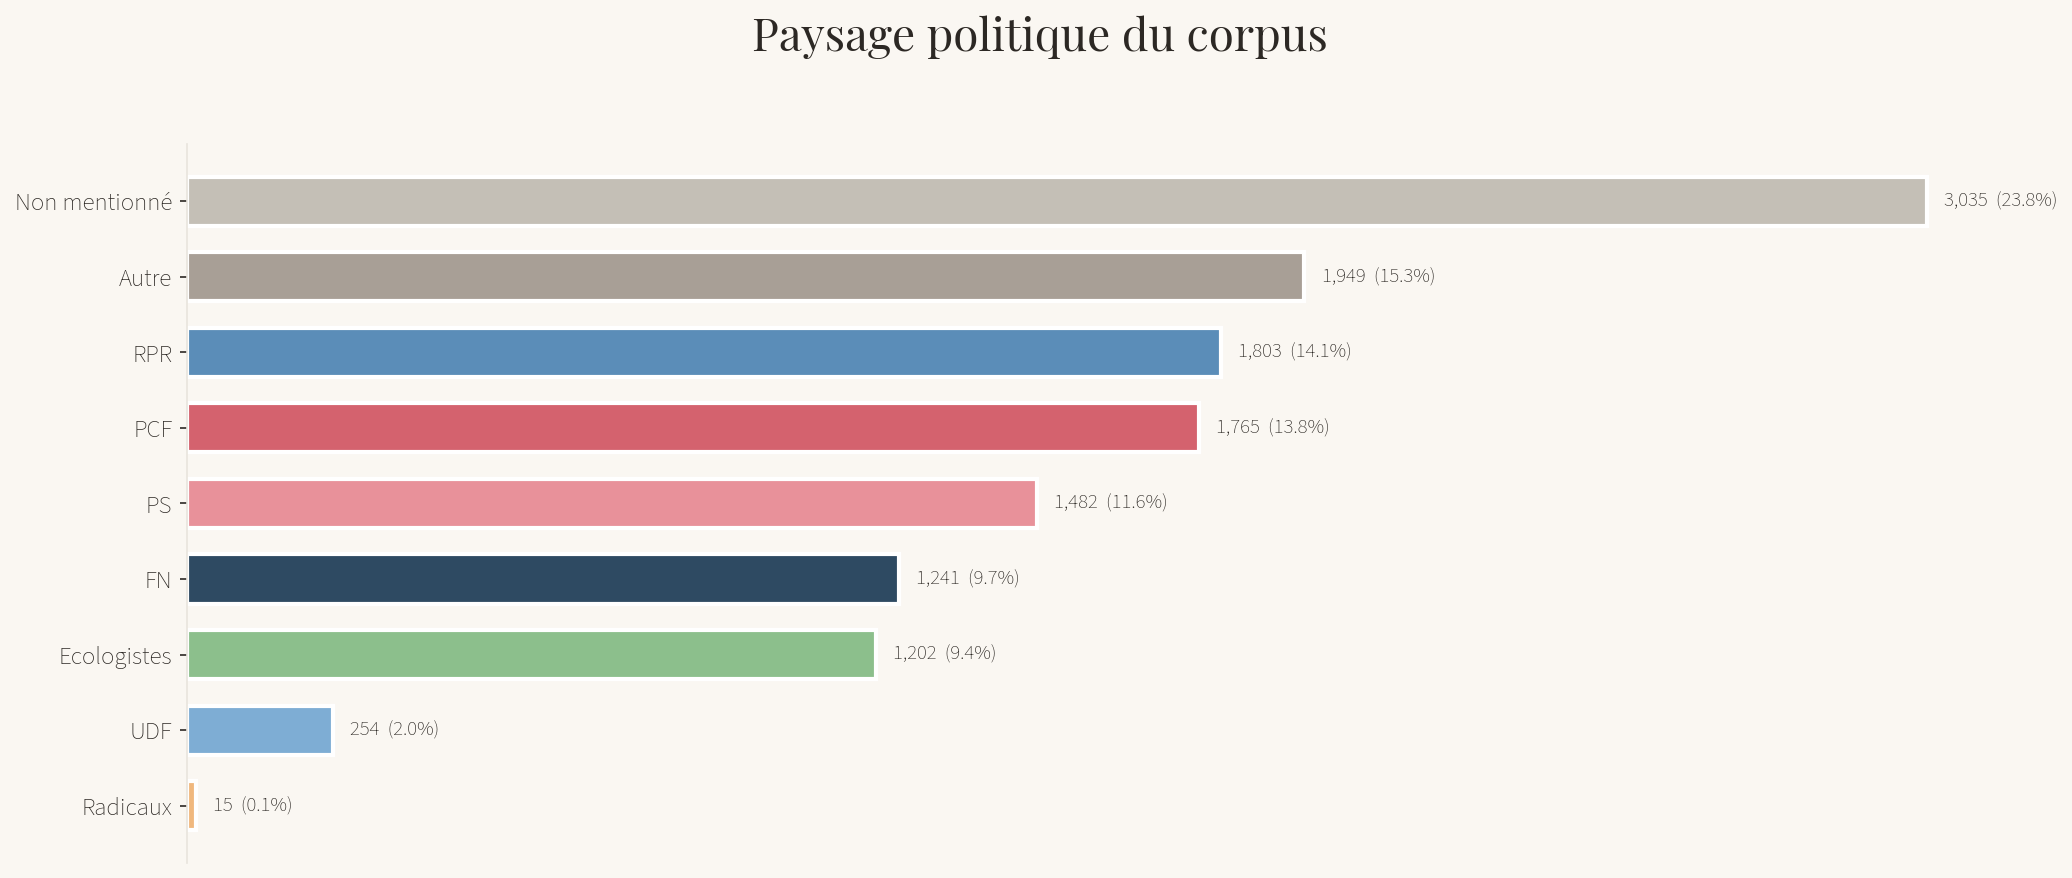

In [10]:
# =============================================================================
# 5. Figure 3 — Paysage politique
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle("Paysage politique du corpus",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.97, color=TEXT_COLOR)

party_counts = df['parti_famille'].value_counts()
parties = party_counts.index.tolist()
counts = party_counts.values

colors = [PARTY_COLORS.get(p, '#A89F96') for p in parties]
bars = ax.barh(range(len(parties)), counts, height=0.65,
               color=colors, edgecolor='white', linewidth=2)

ax.set_yticks(range(len(parties)))
ax.set_yticklabels(parties, fontsize=12, fontfamily=FONT_BODY, fontweight='bold')
ax.invert_yaxis()
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)

for bar, val, party in zip(bars, counts, parties):
    pct = val / len(df) * 100
    ax.text(val + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({pct:.1f}%)', va='center', fontsize=10, color=TEXT_COLOR)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/paysage_politique.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

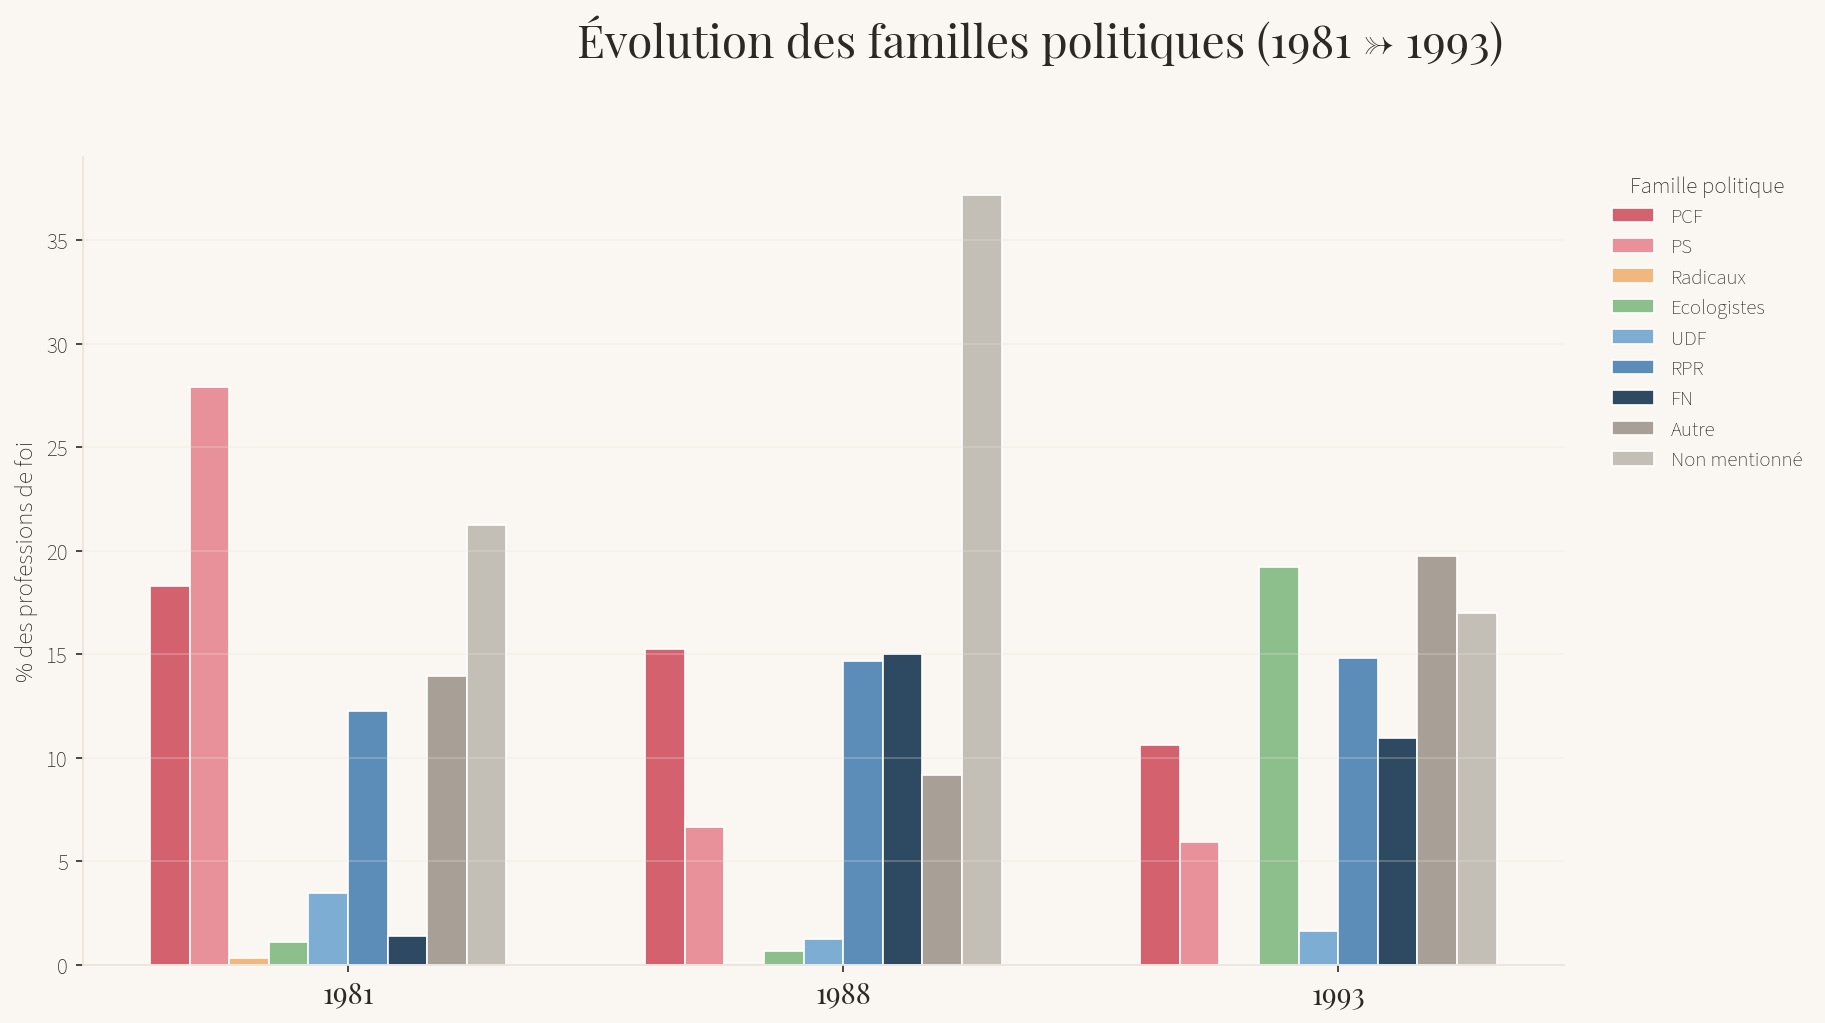

In [11]:
# =============================================================================
# 6. Figure 4 — Évolution des familles politiques par année
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Évolution des familles politiques (1981 → 1993)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.97, color=TEXT_COLOR)

ct = pd.crosstab(df['year'], df['parti_famille'], normalize='index') * 100
ct = ct.sort_index()

main_parties = ['PCF', 'PS', 'Radicaux', 'Ecologistes', 'UDF', 'RPR', 'FN', 'Autre', 'Non mentionné']
main_parties = [p for p in main_parties if p in ct.columns]

x = np.arange(len(ct.index))
width = 0.08
n_parties = len(main_parties)

for i, party in enumerate(main_parties):
    offset = (i - n_parties/2) * width
    color = PARTY_COLORS.get(party, '#A89F96')
    bars = ax.bar(x + offset, ct[party], width=width, label=party,
                  color=color, edgecolor='white', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(ct.index, fontsize=14, fontfamily=FONT_TITLE, fontweight='bold')
ax.set_ylabel("% des professions de foi", fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False,
          fontsize=10, title="Famille politique",
          title_fontproperties={'weight': 'bold', 'size': 11})

plt.tight_layout(rect=[0, 0, 0.88, 0.93])
plt.savefig("../data/evolution_partis.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

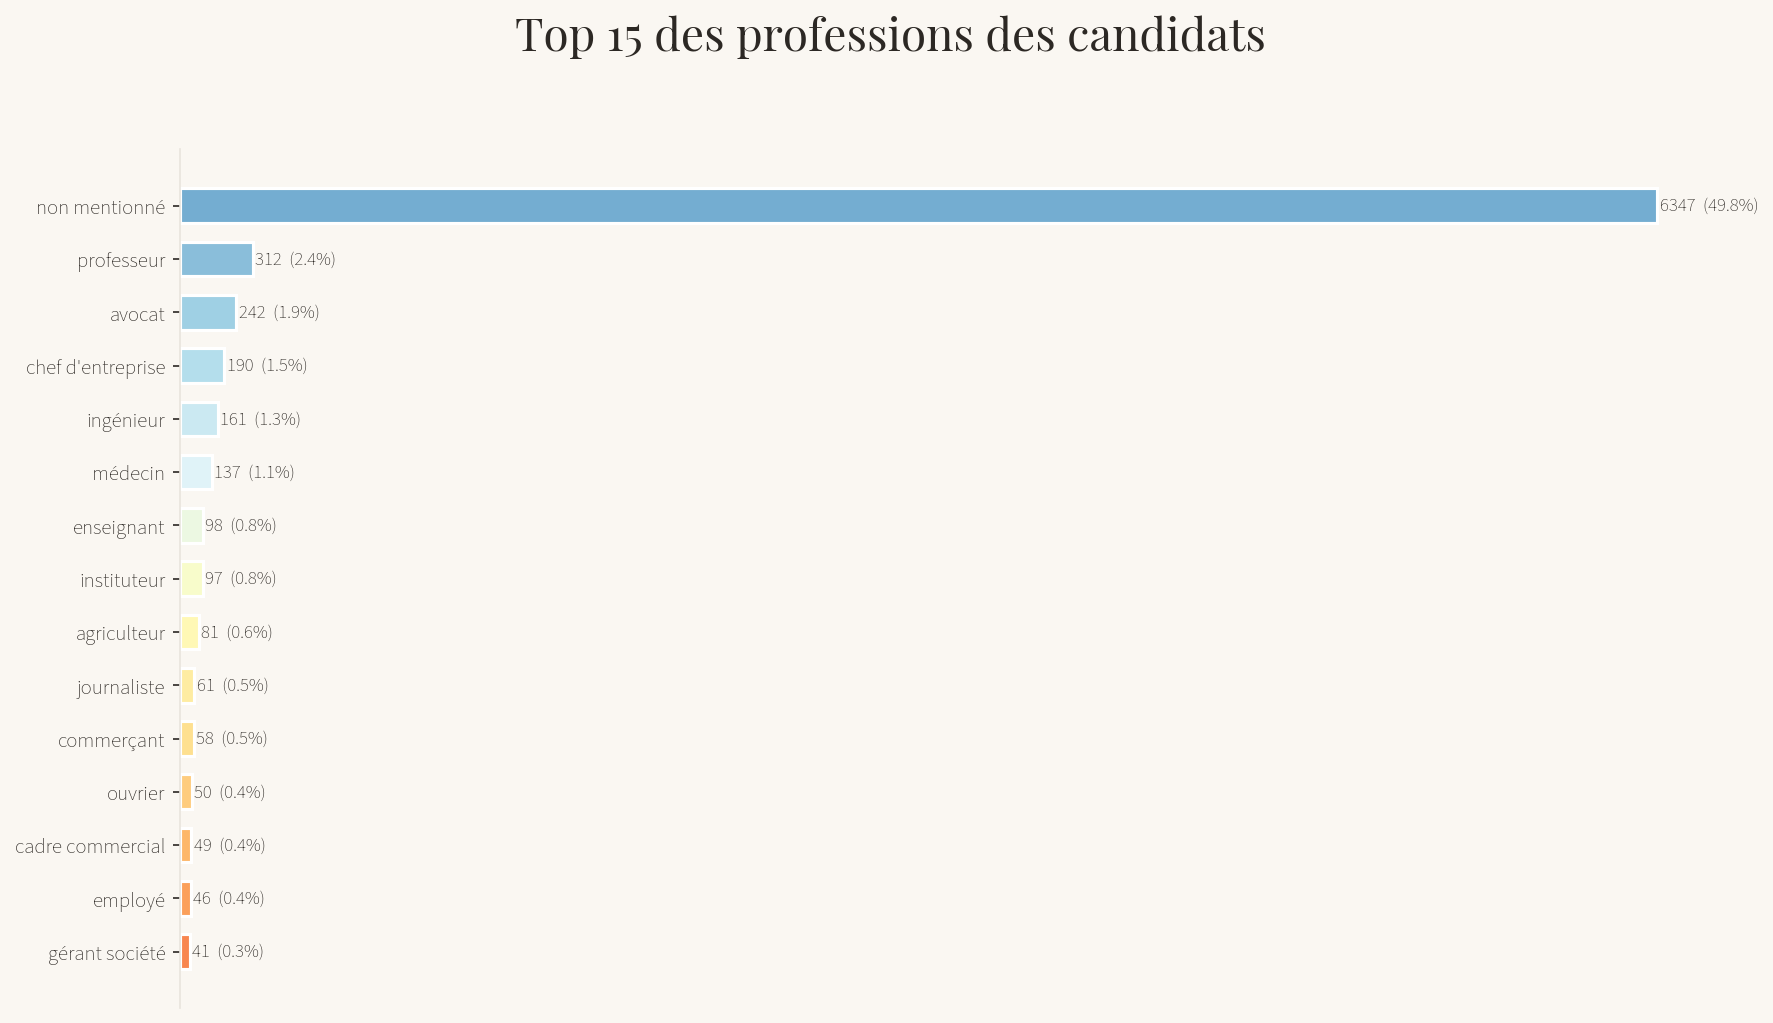

In [12]:
# =============================================================================
# 7. Figure 5 — Top 15 des professions brutes
# =============================================================================
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("Top 15 des professions des candidats",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.97, color=TEXT_COLOR)

prof_counts = df['titulaire-profession'].value_counts().head(15)
cmap = plt.cm.RdYlBu_r
colors_gradient = [cmap(0.2 + 0.6 * i / len(prof_counts)) for i in range(len(prof_counts))]

bars = ax.barh(range(len(prof_counts)), prof_counts.values, height=0.65,
               color=colors_gradient, edgecolor='white', linewidth=1.5)
ax.set_yticks(range(len(prof_counts)))
ax.set_yticklabels(prof_counts.index, fontsize=10, fontfamily=FONT_BODY)
ax.invert_yaxis()
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)

for bar, val in zip(bars, prof_counts.values):
    pct = val / len(df) * 100
    ax.text(val + 10, bar.get_y() + bar.get_height()/2,
            f'{val}  ({pct:.1f}%)', va='center', fontsize=9, color=TEXT_COLOR)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/professions_candidats.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

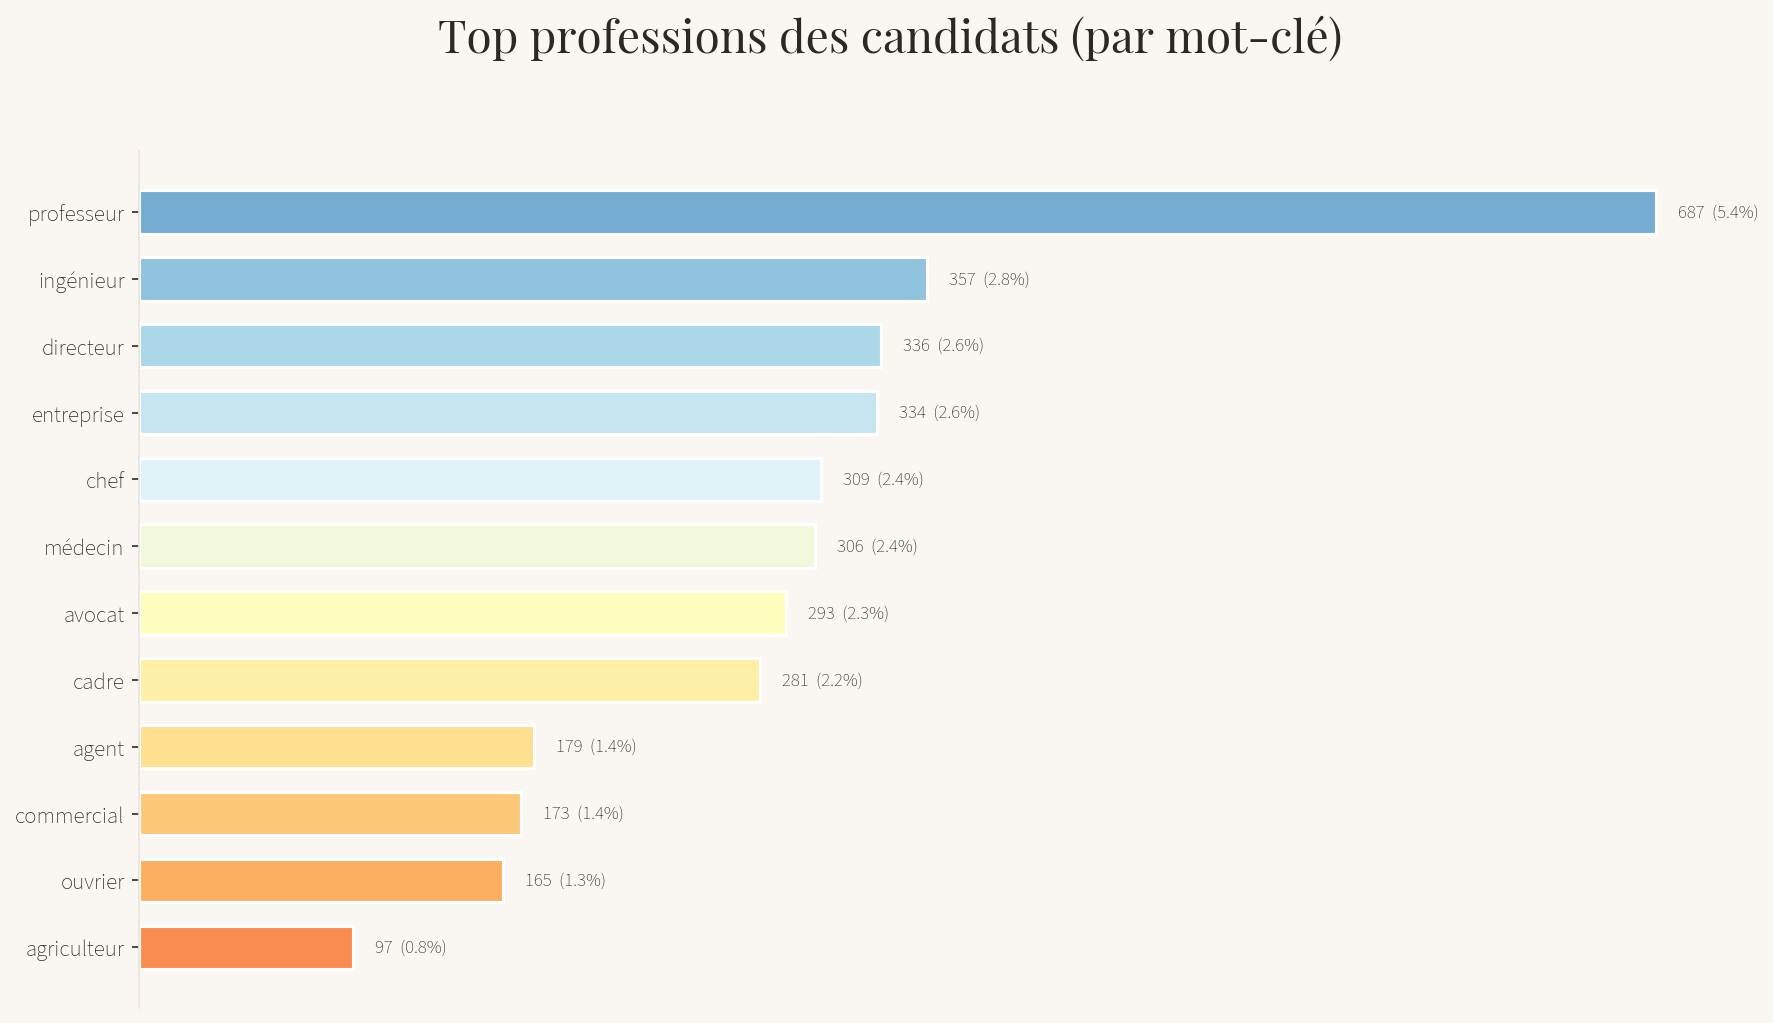

In [13]:
# =============================================================================
# 8. Figure 6 — Professions par mot-clé
# =============================================================================
profession_keywords = [
    'professeur', 'directeur', 'ingénieur', 'cadre', 'chef',
    'entreprise', 'médecin', 'agent', 'avocat', 'agriculteur',
    'ouvrier', 'commercial'
]

prof_kw_counts = {}
for keyword in profession_keywords:
    mask = df['titulaire-profession'].str.contains(keyword, case=False, na=False)
    prof_kw_counts[keyword] = mask.sum()

prof_series = pd.Series(prof_kw_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("Top professions des candidats (par mot-clé)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.97, color=TEXT_COLOR)

cmap = plt.cm.RdYlBu_r
colors_gradient = [cmap(0.2 + 0.6 * i / len(prof_series)) for i in range(len(prof_series))]

bars = ax.barh(range(len(prof_series)), prof_series.values, height=0.65,
               color=colors_gradient, edgecolor='white', linewidth=1.5)
ax.set_yticks(range(len(prof_series)))
ax.set_yticklabels(prof_series.index, fontsize=11, fontfamily=FONT_BODY)
ax.invert_yaxis()
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)

for bar, val in zip(bars, prof_series.values):
    pct = val / len(df) * 100
    ax.text(val + 10, bar.get_y() + bar.get_height()/2,
            f'{val}  ({pct:.1f}%)', va='center', fontsize=9, color=TEXT_COLOR)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/professions_mots_cles.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

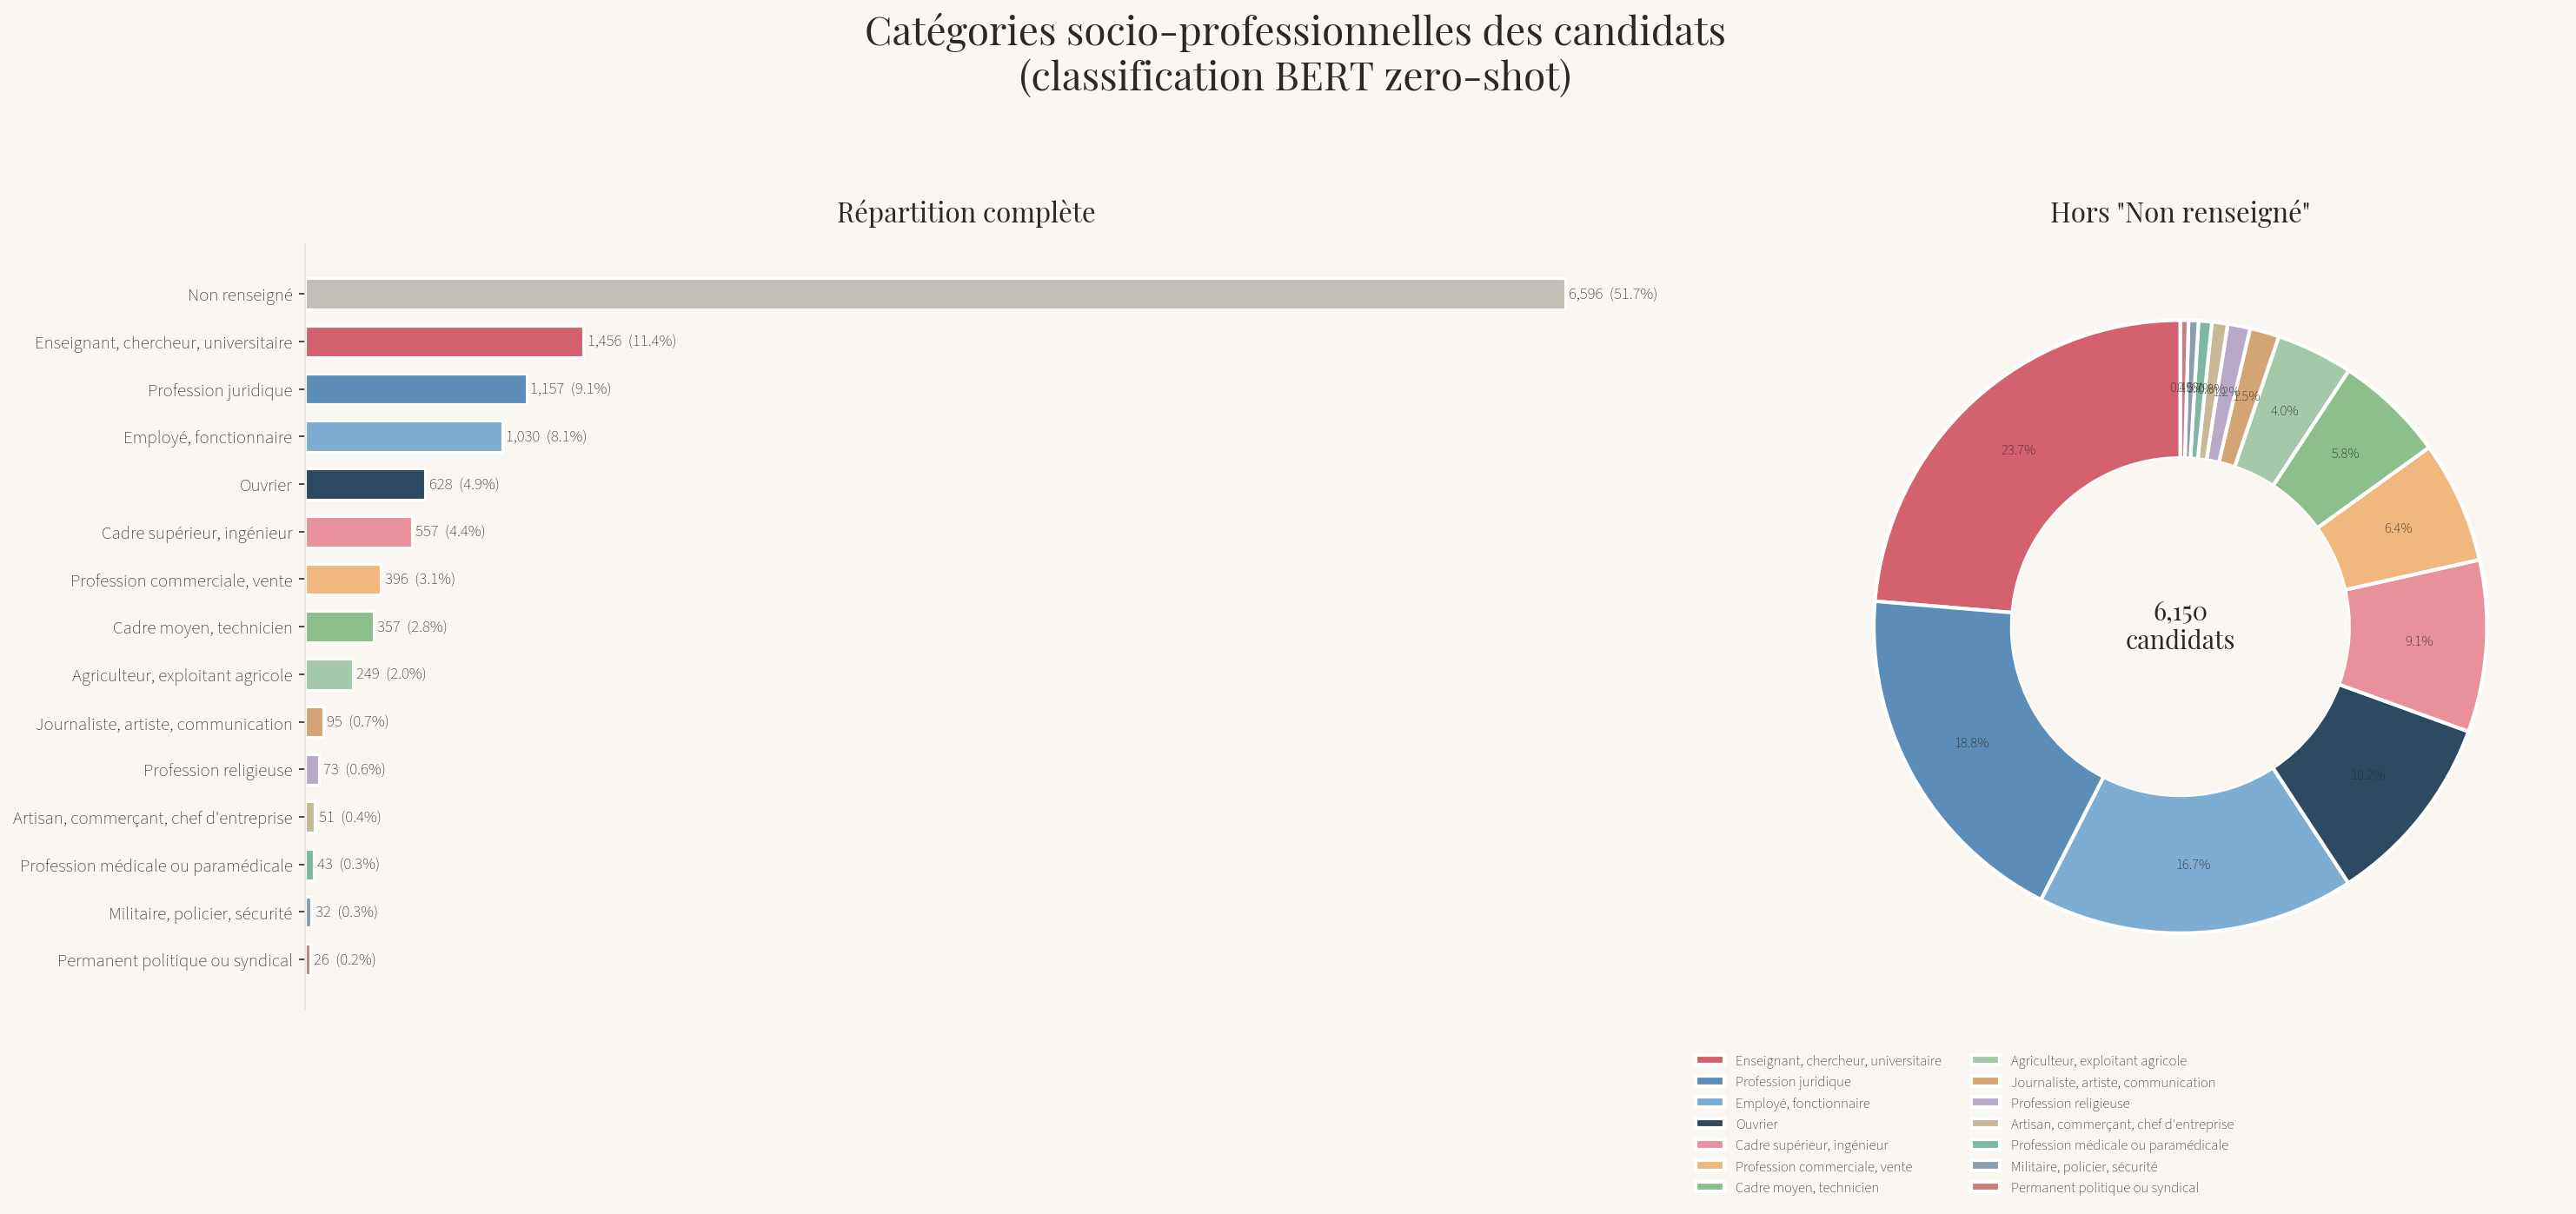


✓ Toutes les figures sauvegardées dans ../data/


In [14]:
# =============================================================================
# 9. Figure 7 — Professions classifiées par BERT (catégories PCS)
# =============================================================================

# Couleurs dédiées aux catégories PCS
PCS_COLORS = {
    'Non renseigné':                          '#C4BFB6',
    'Enseignant, chercheur, universitaire':    '#D4626E',
    'Profession juridique':                    '#5B8DB8',
    'Employé, fonctionnaire':                  '#7EADD4',
    'Ouvrier':                                 '#2E4A62',
    'Cadre supérieur, ingénieur':              '#E8919A',
    'Profession commerciale, vente':           '#F0B87E',
    'Cadre moyen, technicien':                 '#8CBF8C',
    'Agriculteur, exploitant agricole':        '#A3C9A8',
    'Journaliste, artiste, communication':     '#D4A574',
    'Profession religieuse':                   '#B8A9C9',
    'Artisan, commerçant, chef d\'entreprise':  '#C9B896',
    'Profession médicale ou paramédicale':     '#7EB8A2',
    'Militaire, policier, sécurité':           '#8B9DAF',
    'Permanent politique ou syndical':         '#C97E7E',
    'Étudiant, retraité, sans emploi':         '#A89F96',
}

pcs_counts = df['profession_pcs'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(20, 9), gridspec_kw={'width_ratios': [2, 1.2]})
fig.suptitle("Catégories socio-professionnelles des candidats\n(classification BERT zero-shot)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.98, color=TEXT_COLOR)

# ── Gauche : barres horizontales (toutes catégories) ──
ax = axes[0]
categories = pcs_counts.index.tolist()
values = pcs_counts.values
colors = [PCS_COLORS.get(c, '#A89F96') for c in categories]

bars = ax.barh(range(len(categories)), values, height=0.65,
               color=colors, edgecolor='white', linewidth=1.5)
ax.set_yticks(range(len(categories)))
ax.set_yticklabels(categories, fontsize=10, fontfamily=FONT_BODY)
ax.invert_yaxis()
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)

for bar, val in zip(bars, values):
    pct = val / len(df) * 100
    ax.text(val + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({pct:.1f}%)', va='center', fontsize=9, color=TEXT_COLOR)

ax.set_title("Répartition complète", fontfamily=FONT_TITLE, fontsize=15, pad=12)

# ── Droite : donut chart (hors "Non renseigné") ──
ax2 = axes[1]
pcs_filled = pcs_counts.drop('Non renseigné', errors='ignore')
labels = pcs_filled.index.tolist()
sizes = pcs_filled.values
colors_donut = [PCS_COLORS.get(c, '#A89F96') for c in labels]

wedges, texts, autotexts = ax2.pie(
    sizes, labels=None, autopct='%1.1f%%', startangle=90,
    colors=colors_donut, pctdistance=0.78,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2)
)

for autotext in autotexts:
    autotext.set_fontsize(8)
    autotext.set_color(TEXT_COLOR)
    autotext.set_fontweight('bold')

# Légende
ax2.legend(wedges, labels, loc='center left', bbox_to_anchor=(-0.15, -0.15),
           fontsize=8, frameon=False, ncol=2)
ax2.set_title("Hors \"Non renseigné\"", fontfamily=FONT_TITLE, fontsize=15, pad=12)

centre_circle = plt.Circle((0, 0), 0.55, fc=BG_COLOR)
ax2.add_artist(centre_circle)
n_filled = pcs_filled.sum()
ax2.text(0, 0, f'{n_filled:,}\ncandidats', ha='center', va='center',
         fontsize=14, fontweight='bold', fontfamily=FONT_TITLE, color=TEXT_COLOR)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.savefig("../data/professions_pcs_bert.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

print("\n✓ Toutes les figures sauvegardées dans ../data/")

In [15]:
# =============================================================================
# 10. Sauvegarde du DataFrame enrichi
# =============================================================================
df.to_pickle("../data/df_explore.pkl")
print(f"\nDataFrame enrichi sauvegardé : {len(df)} lignes, {len(df.columns)} colonnes")
print(f"Colonnes : {list(df.columns)}")


DataFrame enrichi sauvegardé : 12746 lignes, 52 colonnes
Colonnes : ['filename', 'year', 'election_type', 'text', 'text_length', 'id', 'date', 'subject', 'title', 'contexte-election', 'contexte-tour', 'cote', 'departement', 'departement-nom', 'departement-insee', 'identifiant de circonscription', 'images', 'pdf', 'ocr_url', 'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age', 'titulaire-age-calcule', 'titulaire-age-tranche', 'titulaire-profession', 'titulaire-mandat-en-cours', 'titulaire-mandat-passe', 'titulaire-associations', 'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste', 'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom', 'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule', 'suppleant-age-tranche', 'suppleant-profession', 'suppleant-mandat-en-cours', 'suppleant-mandat-passe', 'suppleant-associations', 'suppleant-autres-statuts', 'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations', 'text_clean', 'tokens', 'n_tokens